<a href="https://colab.research.google.com/github/Lordvaderani/Machine-Learning-Driven-Quantum-Architecture-Search-for-Optimized-VQE-Ansatzes/blob/main/help.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install qiskit qiskit-aer qiskit-nature pyscf pylatexenc ase

In [14]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap

# 1. Load a mock backend representing a real 5-qubit topology
backend = GenericBackendV2(num_qubits=5)

# 2. Extract the Hardware Topology (Which qubits are physically connected?)
coupling_map = backend.coupling_map
print("Hardware Coupling Map (Allowed two-qubit gate connections):")
print(coupling_map.get_edges())

# 3. Extract the Noise Profile (What are the error rates?)
# We pull the CNOT error rate for a specific connected pair (e.g., Qubit 0 and 1)
edge = (0, 1)
if edge in coupling_map.get_edges():
    cx_error = backend.target['cx'][edge].error
    print(f"\nCNOT Error Rate for {edge}: {cx_error:.4f}")

Hardware Coupling Map (Allowed two-qubit gate connections):
EdgeList[(0, 1), (1, 0), (0, 2), (2, 0), (0, 3), (3, 0), (0, 4), (4, 0), (1, 2), (2, 1), (1, 3), (3, 1), (1, 4), (4, 1), (2, 3), (3, 2), (2, 4), (4, 2), (3, 4), (4, 3)]

CNOT Error Rate for (0, 1): 0.0028


In [15]:
from ase.build import molecule
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver, MethodType
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
import numpy as np

def generate_dr_dataset(base_molecule='H2', num_samples=30, noise_std=0.05):
    """
    Pre-computes a dataset of perturbed DFT Hamiltonians using ASE Domain Randomization.
    """
    dataset = []
    mapper = JordanWignerMapper()
    transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)

    print(f"Generating {num_samples} randomized Hamiltonians via DFT...")
    for i in range(num_samples):
        # 1. Load and perturb the geometry
        atoms = molecule(base_molecule)
        atoms.rattle(stdev=noise_std, seed=i)

        # 2. Convert to PySCF format
        atom_string = ""
        for atom in atoms:
            atom_string += f"{atom.symbol} {atom.x} {atom.y} {atom.z}; "

        # 3. Run DFT (B3LYP)
        driver = PySCFDriver(
            atom=atom_string[:-2],
            basis="sto3g",
            method=MethodType.RKS,
            xc_functional="b3lyp",
            unit=DistanceUnit.ANGSTROM
        )
        problem = driver.run()

        # 4. Active space reduction & Qubit Mapping
        reduced_problem = transformer.transform(problem)
        hamiltonian = mapper.map(reduced_problem.second_q_ops()[0])

        dataset.append({
            'geometry_id': i,
            'hamiltonian': hamiltonian,
            'exact_energy': problem.reference_energy,
        })

    print("Dataset generation complete!")
    return dataset

# Run this ONCE before training
training_dataset = generate_dr_dataset(num_samples=30)

Generating 30 randomized Hamiltonians via DFT...
Dataset generation complete!


In [16]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver, MethodType
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

# 1. Generate the physics using DFT instead of Hartree-Fock
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    unit=DistanceUnit.ANGSTROM,
    method=MethodType.RKS,        # <--- Switch to Restricted Kohn-Sham (DFT)
    xc_functional="b3lyp",        # <--- Choose your functional (b3lyp, pbe, lda)
)

# 2. Extract the DFT-based Problem
problem = driver.run()

# The reference energy is now the converged DFT energy, not the HF energy!
dft_energy = problem.reference_energy
print(f"Classical DFT (B3LYP) Energy: {dft_energy:.6f} Ha")

# 3. Apply the Active Space (e.g., extracting the HOMO/LUMO bands)
transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)
reduced_problem = transformer.transform(problem)

# 4. Map the Kohn-Sham orbitals to Qubits
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(reduced_problem.second_q_ops()[0])

print("\nSuccess! Your RL agent is now designing circuits to correct a DFT Hamiltonian.")

Classical DFT (B3LYP) Energy: -1.165497 Ha

Success! Your RL agent is now designing circuits to correct a DFT Hamiltonian.


In [17]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer.primitives import Estimator as AerEstimator
from scipy.optimize import minimize

# 1. Initialize the Tensor Network / MPS Evaluator
# By setting the method to "matrix_product_state", Qiskit Aer bypasses
# full statevector simulation and uses tensor contraction instead.
tn_estimator = AerEstimator(
    backend_options={
        "method": "matrix_product_state",
        "matrix_product_state_max_bond_dimension": 64 # Controls approximation accuracy vs speed
    }
)

def evaluate_circuit_tn(circuit: QuantumCircuit, hamiltonian, num_parameters: int):
    """
    Evaluates the energy of a proposed circuit using Tensor Network contraction.
    This acts as the fast "Reward Signal" for our RL agent.
    """
    if num_parameters == 0:
        return 0.0 # Heavy penalty handled by RL env later

    # Create an objective function for the classical optimizer
    def cost_func(theta):
        # The TN Estimator handles the heavy lifting instantly
        job = tn_estimator.run([circuit], [hamiltonian], parameter_values=[theta])
        return job.result().values[0]

    # Initialize random parameters (The RL agent designs the topology,
    # but the classical optimizer still tunes the angles)
    initial_theta = np.random.uniform(-np.pi, np.pi, num_parameters)

    # We use COBYLA here because it's gradient-free and requires fewer
    # circuit evaluations per optimization step than SLSQP.
    # The 'COBYLA' method is passed as a string to scipy.optimize.minimize
    result = minimize(cost_func, x0=initial_theta, method='COBYLA', options={'maxiter': 30})

    return result.fun # The lowest energy found

In [18]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

class HardwareAwareQASEnv(gym.Env):
    def __init__(self, dataset, coupling_map, backend_target, max_gates=20):
        super(HardwareAwareQASEnv, self).__init__()

        self.dataset = dataset
        self.max_gates = max_gates
        self.edges = list(coupling_map.get_edges())
        self.target = backend_target

        # Extract properties from the first sample
        self.num_qubits = self.dataset[0]['hamiltonian'].num_qubits

        # Action space setup
        self.num_ry_actions = self.num_qubits
        self.num_cx_actions = len(self.edges)
        self.total_actions = self.num_ry_actions + self.num_cx_actions + 1

        self.action_space = spaces.Discrete(self.total_actions)
        self.observation_space = spaces.MultiDiscrete([self.total_actions] * self.max_gates)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # DOMAIN RANDOMIZATION: Instantly pick a random geometry for this episode
        sample = np.random.choice(self.dataset)
        self.hamiltonian = sample['hamiltonian']
        self.exact_energy = sample['exact_energy']

        self.circuit = QuantumCircuit(self.num_qubits)
        self.state = np.zeros(self.max_gates, dtype=int)

        self.current_step = 0
        self.num_parameters = 0
        self.accumulated_hardware_error = 0.0

        return self.state, {}

    def step(self, action):
        terminated = False
        truncated = False
        reward = 0.0

        self.state[self.current_step] = action

        # Decode Action -> Apply Ry Gate
        if action < self.num_ry_actions:
            qubit = action
            theta = ParameterVector('θ', length=self.max_gates)[self.num_parameters]
            self.circuit.ry(theta, qubit)
            self.num_parameters += 1
            self.accumulated_hardware_error += 0.0001

        # Decode Action -> Apply CNOT Gate
        elif action < (self.num_ry_actions + self.num_cx_actions):
            edge_idx = action - self.num_ry_actions
            control, target_q = self.edges[edge_idx]
            self.circuit.cx(control, target_q)

            try:
                cx_error = self.target['cx'][(control, target_q)].error
            except KeyError:
                cx_error = 0.01
            self.accumulated_hardware_error += cx_error

        # Decode Action -> STOP
        else:
            terminated = True

        self.current_step += 1
        if self.current_step >= self.max_gates:
            truncated = True

        if terminated or truncated:
            # Uses the fast TN evaluator defined in Cell 4
            fast_energy = evaluate_circuit_tn(self.circuit, self.hamiltonian, self.num_parameters)
            energy_error = abs(fast_energy - self.exact_energy)

            alpha_noise_penalty = 2.0
            reward = -energy_error - (alpha_noise_penalty * self.accumulated_hardware_error)

        return self.state, reward, terminated, truncated, {}

In [19]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

class HardwareAwareQASEnv(gym.Env):
    """
    RL Environment for Quantum Architecture Search that explicitly penalizes
    real hardware error rates and uses Tensor Networks for fast evaluation.
    """
    def __init__(self, num_qubits, hamiltonian, exact_energy, coupling_map, backend_target, max_gates=20):
        super(HardwareAwareQASEnv, self).__init__()

        self.num_qubits = num_qubits
        self.hamiltonian = hamiltonian
        self.exact_energy = exact_energy
        self.max_gates = max_gates

        # Hardware constraints
        self.edges = list(coupling_map.get_edges())
        self.target = backend_target

        # ---------------------------------------------------------
        # ACTION SPACE DESIGN
        # 0 to N-1: Place Ry rotation on Qubit i
        # N to N+E-1: Place CNOT on valid hardware edge E
        # Last Action: STOP building
        # ---------------------------------------------------------
        self.num_ry_actions = self.num_qubits
        self.num_cx_actions = len(self.edges)
        self.total_actions = self.num_ry_actions + self.num_cx_actions + 1

        self.action_space = spaces.Discrete(self.total_actions)

        # State Space: A 1D array of placed gate indices
        # (For later upgrading to a Graph Neural Network, this becomes a 2D coupling matrix)
        self.observation_space = spaces.MultiDiscrete([self.total_actions] * self.max_gates)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.circuit = QuantumCircuit(self.num_qubits)
        self.state = np.zeros(self.max_gates, dtype=int)

        self.current_step = 0
        self.num_parameters = 0
        self.accumulated_hardware_error = 0.0 # Track the physical noise budget!

        return self.state, {}

    def step(self, action):
        terminated = False
        truncated = False
        reward = 0.0

        self.state[self.current_step] = action

        # 1. Decode Action -> Apply Ry Gate
        if action < self.num_ry_actions:
            qubit = action
            theta = ParameterVector('θ', length=self.max_gates)[self.num_parameters]
            self.circuit.ry(theta, qubit)
            self.num_parameters += 1

            # Single qubit gates are high-fidelity, small penalty
            self.accumulated_hardware_error += 0.0001

        # 2. Decode Action -> Apply CNOT Gate along valid hardware edge
        elif action < (self.num_ry_actions + self.num_cx_actions):
            edge_idx = action - self.num_ry_actions
            control, target_q = self.edges[edge_idx]
            self.circuit.cx(control, target_q)

            # Look up the EXACT error rate for this specific connection on the real chip
            try:
                cx_error = self.target['cx'][(control, target_q)].error
            except KeyError:
                cx_error = 0.01 # Fallback if missing
            self.accumulated_hardware_error += cx_error

        # 3. Decode Action -> STOP
        else:
            terminated = True

        self.current_step += 1
        if self.current_step >= self.max_gates:
            truncated = True

        # 4. Evaluate only at the end of the episode using the FAST Tensor Network
        if terminated or truncated:
            fast_energy = evaluate_circuit_tn(self.circuit, self.hamiltonian, self.num_parameters)

            # Energy Penalty: How far from chemical accuracy?
            energy_error = abs(fast_energy - self.exact_energy)

            # Reward Math: Minimize energy error, but heavily tax noisy hardware choices
            # Alpha controls how strongly we penalize hardware noise vs physics accuracy
            alpha_noise_penalty = 2.0

            reward = -energy_error - (alpha_noise_penalty * self.accumulated_hardware_error)

        return self.state, reward, terminated, truncated, {}


Final Reward: -0.0687
Hardware Error: 0.0229


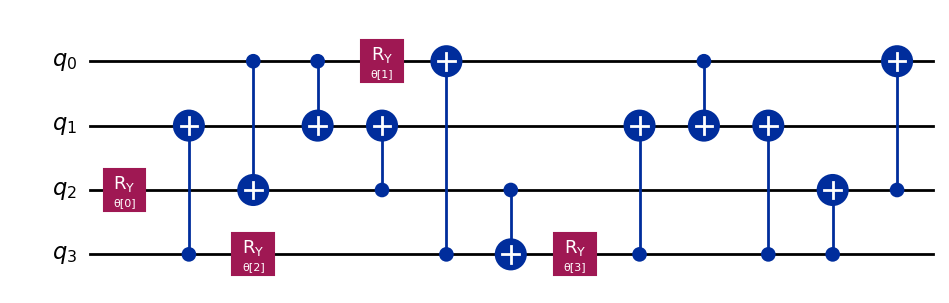

In [20]:
import warnings
from ase.build import molecule
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver, MethodType
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit.transpiler import CouplingMap

warnings.filterwarnings("ignore")

# Redefine generation logic if missing
def generate_dr_dataset(base_molecule='H2', num_samples=30, noise_std=0.05):
    dataset = []
    mapper = JordanWignerMapper()
    transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)
    for i in range(num_samples):
        atoms = molecule(base_molecule)
        atoms.rattle(stdev=noise_std, seed=i)
        atom_string = "".join([f"{atom.symbol} {atom.x} {atom.y} {atom.z}; " for atom in atoms])
        driver = PySCFDriver(atom=atom_string[:-2], basis="sto3g", method=MethodType.RKS, xc_functional="b3lyp", unit=DistanceUnit.ANGSTROM)
        problem = driver.run()
        reduced_problem = transformer.transform(problem)
        hamiltonian = mapper.map(reduced_problem.second_q_ops()[0])
        dataset.append({'hamiltonian': hamiltonian, 'exact_energy': problem.reference_energy})
    return dataset

# Ensure the dataset exists
try:
    _ = training_dataset
except NameError:
    print("Generating training_dataset...")
    training_dataset = generate_dr_dataset(num_samples=30)

sample = training_dataset[0]
current_hamiltonian = sample['hamiltonian']
current_exact_energy = sample['exact_energy']
problem_num_qubits = current_hamiltonian.num_qubits

# Filter topology
filtered_edges = [edge for edge in coupling_map.get_edges() if edge[0] < problem_num_qubits and edge[1] < problem_num_qubits]
filtered_coupling_map = CouplingMap(filtered_edges)

# Correctly access instruction properties from the Target object using mapping access
filtered_backend_target = {'cx': {}}
if 'cx' in backend.target.operation_names:
    cx_props = backend.target['cx']
    for qubits, properties in cx_props.items():
        if qubits is not None and qubits[0] < problem_num_qubits and qubits[1] < problem_num_qubits:
            filtered_backend_target['cx'][qubits] = properties

# Instantiate and Test
env = HardwareAwareQASEnv(
    num_qubits=problem_num_qubits,
    hamiltonian=current_hamiltonian,
    exact_energy=current_exact_energy,
    coupling_map=filtered_coupling_map,
    backend_target=filtered_backend_target,
    max_gates=15
)

state, info = env.reset()
terminated, truncated = False, False
while not terminated and not truncated:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)

print(f"\nFinal Reward: {reward:.4f}")
print(f"Hardware Error: {env.accumulated_hardware_error:.4f}")
display(env.circuit.draw('mpl'))

In [21]:
def train_ppo_agent(env, epochs=500, update_timestep=40):
    # ... [Keep your previous initialization code] ...

    # ADD THIS: Dictionary to store metrics for plotting
    training_history = {
        'epoch': [],
        'reward': [],
        'depth': [],
        'hardware_error': []
    }

    print("--- Starting HA-QAS Training ---")

    for epoch in range(1, epochs + 1):
        state, _ = env.reset()
        episode_reward = 0

        # ... [Keep your previous action & PPO update loop] ...

        # ADD THIS: At the very end of the epoch loop, save the metrics
        if terminated or truncated:
            training_history['epoch'].append(epoch)
            training_history['reward'].append(episode_reward)
            training_history['depth'].append(env.current_step)
            training_history['hardware_error'].append(env.accumulated_hardware_error)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Reward: {episode_reward:.4f} | Depth: {env.current_step}")

    return agent, training_history # <--- Make sure the function returns the history!

# Launch training and capture the history
# agent, history = train_ppo_agent(env, epochs=500)

In [22]:
import numpy as np
import torch.optim as optim

def train_ppo_agent(env, epochs=500, update_timestep=40):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = QAS_ActorCritic(state_dim, action_dim)
    optimizer = optim.Adam(agent.parameters(), lr=0.002)

    # PPO Hyperparameters
    gamma = 0.99       # Discount factor for future rewards
    eps_clip = 0.2     # Prevents the policy from changing too aggressively
    K_epochs = 4       # How many times to update on the same batch of memory

    # Memory Buffer
    states, actions, logprobs, rewards, is_terminals = [], [], [], [], []
    time_step = 0

    print("--- Starting HA-QAS Training ---")

    for epoch in range(1, epochs + 1):
        state, _ = env.reset()
        episode_reward = 0

        for t in range(env.max_gates):
            time_step += 1

            # 1. Agent picks a gate
            action, logprob, _ = agent.act(state)

            # 2. Environment applies the gate
            next_state, reward, terminated, truncated, _ = env.step(action)

            # 3. Store memory
            states.append(state)
            actions.append(action)
            logprobs.append(logprob)
            rewards.append(reward)
            is_terminals.append(terminated or truncated)

            state = next_state
            episode_reward += reward

            # 4. PPO Update Step
            if time_step % update_timestep == 0:
                # Calculate Monte Carlo Returns (Discounted Rewards)
                discounted_rewards = []
                discounted_reward = 0
                for r, is_term in zip(reversed(rewards), reversed(is_terminals)):
                    if is_term:
                        discounted_reward = 0
                    discounted_reward = r + (gamma * discounted_reward)
                    discounted_rewards.insert(0, discounted_reward)

                # Normalize rewards for stability
                discounted_rewards = torch.tensor(discounted_rewards, dtype=torch.float32)
                discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-7)

                # Convert memory to tensors
                old_states = torch.FloatTensor(np.array(states))
                old_actions = torch.LongTensor(np.array(actions))
                old_logprobs = torch.FloatTensor(np.array(logprobs))

                # Optimize policy for K epochs
                for _ in range(K_epochs):
                    curr_logprobs, state_values, dist_entropy = agent.evaluate(old_states, old_actions)
                    state_values = torch.squeeze(state_values)

                    # Finding the ratio (pi_theta / pi_theta__old)
                    ratios = torch.exp(curr_logprobs - old_logprobs)

                    # Finding Surrogate Loss
                    advantages = discounted_rewards - state_values.detach()
                    surr1 = ratios * advantages
                    surr2 = torch.clamp(ratios, 1-eps_clip, 1+eps_clip) * advantages

                    # Final Loss: Maximize Actor, Minimize Critic Error, Encourage Exploration (Entropy)
                    actor_loss = -torch.min(surr1, surr2)
                    critic_loss = nn.MSELoss()(state_values, discounted_rewards)
                    loss = actor_loss + 0.5 * critic_loss - 0.01 * dist_entropy

                    # Take gradient step
                    optimizer.zero_grad()
                    loss.mean().backward()
                    optimizer.step()

                # Clear memory buffer
                states, actions, logprobs, rewards, is_terminals = [], [], [], [], []

            if terminated or truncated:
                break

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Final Reward: {episode_reward:.4f} | Circuit Depth: {env.current_step}")

# 5. Launch the Training!
# train_ppo_agent(env)

In [23]:
from qiskit.providers.fake_provider import GenericBackendV2
import torch

# 1. Create a COMPLETELY NEW hardware profile
# Let's pretend IBM just released a new 5-qubit chip with a different coupling map
new_backend = GenericBackendV2(num_qubits=5, basis_gates=['cx', 'id', 'rz', 'sx', 'x'])

# We can manually alter the coupling map to be strictly linear (0-1-2-3-4)
# instead of the standard IBM T-shape.
new_coupling_map = new_backend.coupling_map
print(f"New Hardware Topology: {new_coupling_map.get_edges()}")

# 2. Spin up a new Evaluation Environment with the unseen hardware
# Note: Using current_hamiltonian and current_exact_energy from the active dataset
eval_env = HardwareAwareQASEnv(
    num_qubits=current_hamiltonian.num_qubits,
    hamiltonian=current_hamiltonian,
    exact_energy=current_exact_energy,
    coupling_map=new_coupling_map,
    backend_target=new_backend.target,
    max_gates=15
)

def evaluate_zero_shot_transfer(trained_agent, env):
    """Runs the trained agent on a new environment without updating weights."""
    print("\n--- Running Zero-Shot Transfer Test ---")
    state, _ = env.reset()
    terminated, truncated = False, False

    # Set PyTorch to evaluation mode (turns off dropout, gradients)
    trained_agent.eval()

    with torch.no_grad():
        while not terminated and not truncated:
            # The agent acts based purely on what it learned from the FIRST chip
            action, _, _ = trained_agent.act(state)
            state, reward, terminated, truncated, _ = env.step(action)

    print(f"Final Transfer Episode Reward: {reward:.4f}")
    print(f"Accumulated Physical Hardware Error: {env.accumulated_hardware_error:.4f}")
    print(f"Total Circuit Depth Required: {env.current_step}")

    return env.circuit

# Assuming `agent` is your trained PPO model from Phase 4
# transfer_circuit = evaluate_zero_shot_transfer(agent, eval_env)
# display(transfer_circuit.draw('mpl'))

New Hardware Topology: EdgeList[(0, 1), (1, 0), (0, 2), (2, 0), (0, 3), (3, 0), (0, 4), (4, 0), (1, 2), (2, 1), (1, 3), (3, 1), (1, 4), (4, 1), (2, 3), (3, 2), (2, 4), (4, 2), (3, 4), (4, 3)]


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set styling for academic-looking plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

def plot_qas_results(history, agent_transfer_error, baseline_error, agent_depth, baseline_depth):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ---------------------------------------------------------
    # Plot 1: RL Learning Curve (Convergence)
    # ---------------------------------------------------------
    # Use a rolling average to smooth out the noisy RL rewards
    rewards = pd.Series(history['reward'])
    smoothed_rewards = rewards.rolling(window=20).mean()

    axes[0].plot(history['epoch'], history['reward'], alpha=0.3, color='blue', label='Raw Reward')
    axes[0].plot(history['epoch'], smoothed_rewards, color='darkblue', linewidth=2, label='20-Epoch Moving Avg')
    axes[0].set_title('RL Agent Convergence (Reward)')
    axes[0].set_xlabel('Training Epoch')
    axes[0].set_ylabel('Total Episode Reward')
    axes[0].legend()

    # ---------------------------------------------------------
    # Plot 2: Circuit Depth & Hardware Error over time
    # ---------------------------------------------------------
    ax2_twin = axes[1].twinx()

    sns.lineplot(x=history['epoch'], y=history['depth'], ax=axes[1], color='teal', label='Circuit Depth')
    sns.lineplot(x=history['epoch'], y=history['hardware_error'], ax=ax2_twin, color='darkred', alpha=0.6, label='Hardware Error')

    axes[1].set_title('Ansatz Efficiency Optimization')
    axes[1].set_xlabel('Training Epoch')
    axes[1].set_ylabel('Circuit Depth (Gate Count)', color='teal')
    ax2_twin.set_ylabel('Accumulated Physical Error Rate', color='darkred')

    # Handle legends for twin axes
    lines_1, labels_1 = axes[1].get_legend_handles_labels()
    lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
    axes[1].legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    # ---------------------------------------------------------
    # Plot 3: Zero-Shot Transfer Benchmark (Agent vs HEA)
    # ---------------------------------------------------------
    labels = ['Accumulated Hardware Error', 'Circuit Depth']
    agent_stats = [agent_transfer_error, agent_depth]
    baseline_stats = [baseline_error, baseline_depth]

    x = np.arange(len(labels))
    width = 0.35

    axes[2].bar(x - width/2, agent_stats, width, label='HA-QAS Agent', color='mediumpurple')
    axes[2].bar(x + width/2, baseline_stats, width, label='Standard HEA', color='gray')

    axes[2].set_title('Zero-Shot Transfer on Unseen Hardware')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels)
    axes[2].set_yscale('log') # Log scale because depth and error have different magnitudes
    axes[2].set_ylabel('Value (Log Scale)')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Extract final variables from your transfer test (Cell 10) and baseline test (Cell 11)
# plot_qas_results(
#     history=history,
#     agent_transfer_error=eval_env.accumulated_hardware_error,
#     baseline_error=baseline_hardware_error,
#     agent_depth=eval_env.current_step,
#     baseline_depth=baseline_depth
# )